First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

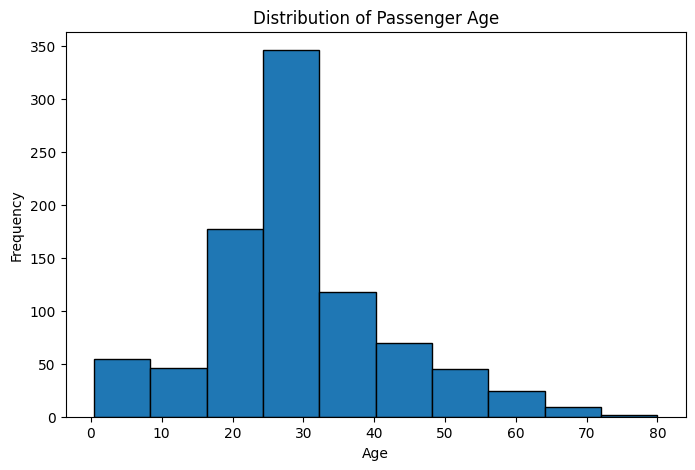

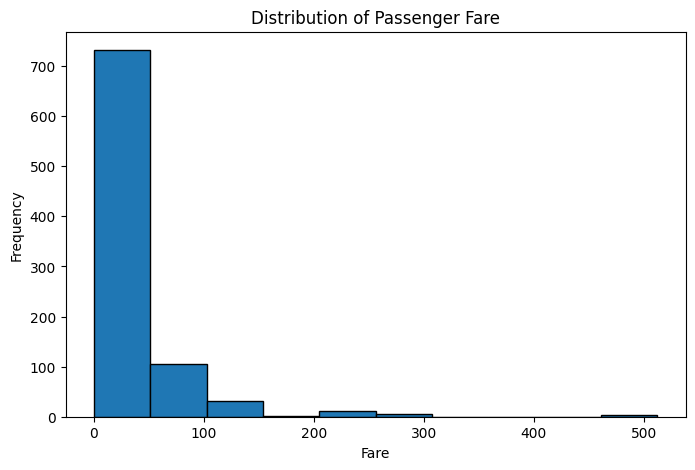

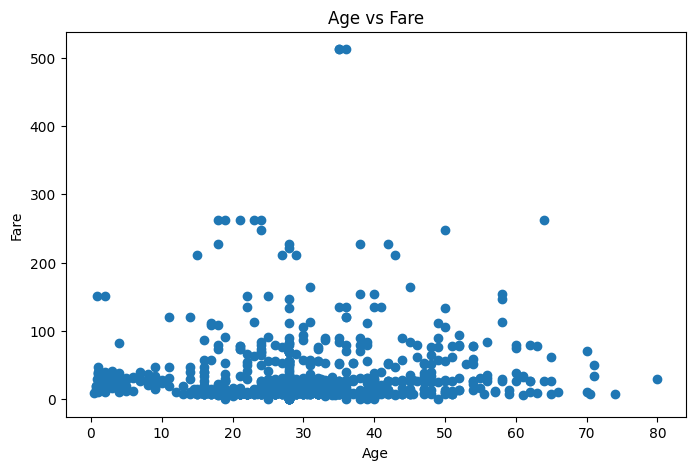

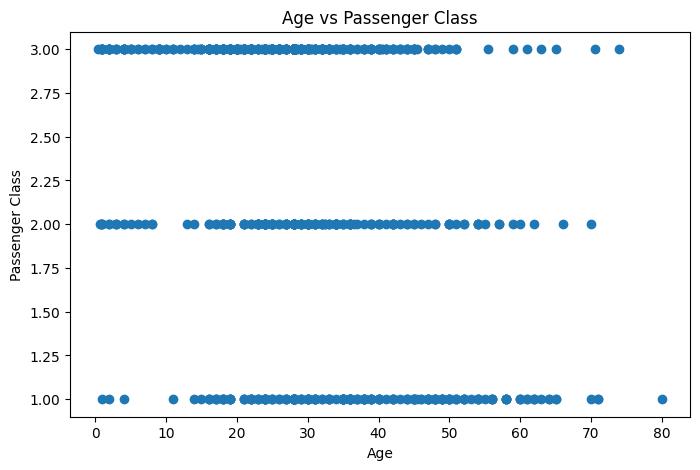


Correlation Matrix:
             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.034212 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.064910 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.339898  0.083081  0.018443   
Age             0.034212 -0.064910 -0.339898  1.000000 -0.233296 -0.172482   
SibSp          -0.057527 -0.035322  0.083081 -0.233296  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.172482  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096688  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.096688  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  


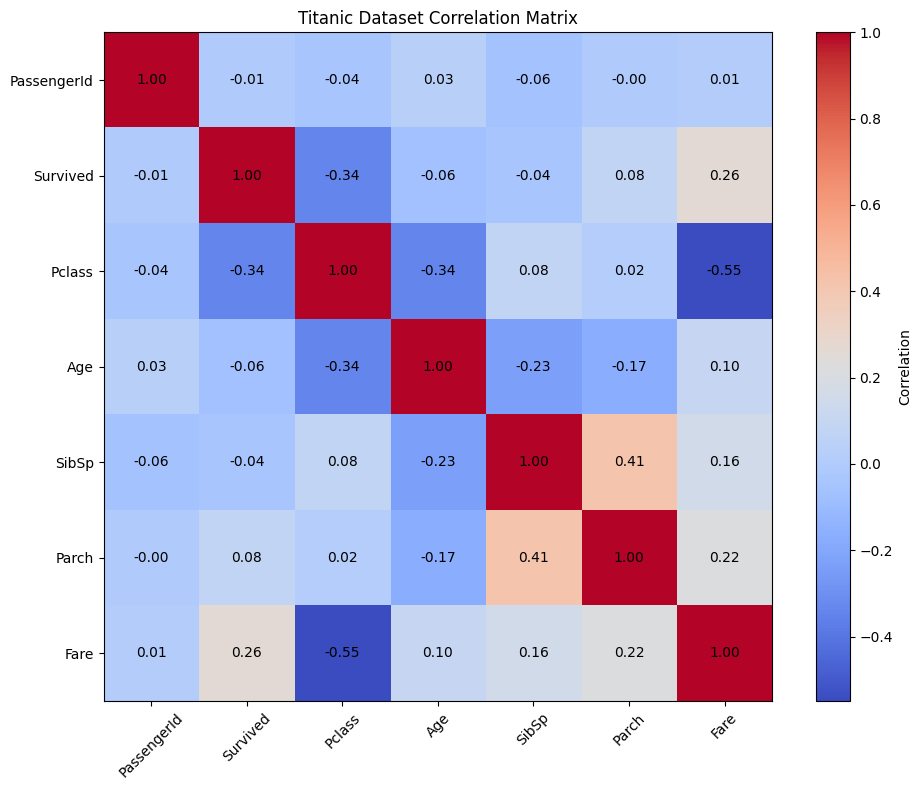


Cleaned Dataset:
     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

print("First 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Select numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns

# Fill missing numerical values with median
for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

# Select categorical columns
categorical_columns = df.select_dtypes(include="object").columns

# Fill missing categorical values with mode
for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

print("\nMissing values after cleaning:")
print(df.isnull().sum())

# Summary statistics
print("\nSummary statistics:")
print(df.describe())

# Mean
print("\nMean:")
print(df[numeric_columns].mean())

# Median
print("\nMedian:")
print(df[numeric_columns].median())

# Standard deviation
print("\nStandard deviation:")
print(df[numeric_columns].std())


# -----------------------------------
# Histogram of Age
# -----------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    df["Age"],
    bins=10,
    edgecolor="black"
)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()


# -----------------------------------
# Histogram of Fare
# -----------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    df["Fare"],
    bins=10,
    edgecolor="black"
)

plt.title("Distribution of Passenger Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()


# -----------------------------------
# Scatter Plot: Age vs Fare
# -----------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Age"],
    df["Fare"]
)

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()


# -----------------------------------
# Scatter Plot: Age vs Passenger Class
# -----------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Age"],
    df["Pclass"]
)

plt.title("Age vs Passenger Class")
plt.xlabel("Age")
plt.ylabel("Passenger Class")

plt.show()


# -----------------------------------
# Correlation Matrix
# -----------------------------------

correlation_matrix = df[numeric_columns].corr()

print("\nCorrelation Matrix:")
print(correlation_matrix)


plt.figure(figsize=(10, 8))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    interpolation="nearest"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Titanic Dataset Correlation Matrix")


# Add correlation values
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):

        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.show()


# -----------------------------------
# Display cleaned dataset
# -----------------------------------

print("\nCleaned Dataset:")
print(df)


# Save cleaned dataset
df.to_csv("Titanic_cleaned.csv", index=False)

print("\nEDA completed successfully.")
